# Model Recovery Analysis

This notebook analyzes the results of the model recovery experiment, where different models are used to generate synthetic data and then all models are fit to that data to see which model best recovers the true generating model.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from popy.config import PROJECT_PATH_LOCAL

/home/uzsombi/.config/matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /tmp/matplotlib-0l7oapmy because there was an issue with the default path (/home/uzsombi/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## Load Results

In [2]:
# Load the model recovery results
results_path = os.path.join(PROJECT_PATH_LOCAL, "notebooks", "behav_modeling", "results", "recovery", "model_recovery.csv")
df = pd.read_csv(results_path)

# sort by model_true, iteration, model_fitted
df = df.sort_values(by=['model_true', 'iteration', 'model_fitted']).reset_index(drop=True)

# remove when beta < 5 or epsilon > .4
#df = df[(df["beta"] >= 8) | (df["epsilon"] <= 0.3)]
 
print(f"Loaded {len(df)} simulations")
df

Loaded 1600 simulations


,model_true,model_fitted,iteration,alpha,beta,stickiness_bias,epsilon_recovered,LPT_best,alpha_recovered,beta_recovered,V0_recovered,epsilon,V0,stickiness_bias_recovered
0,Foraging,Foraging,0,0.492154,14.751451,NaN,NaN,0.801893,0.546924,16.408894,0.119291,NaN,0.145550,NaN
1,Foraging,Inferential RL - stickiness,0,0.492154,14.751451,NaN,NaN,0.760517,0.220789,6.997518,NaN,NaN,0.145550,2.262847
2,Foraging,Standard RL - stickiness,0,0.492154,14.751451,NaN,NaN,0.777491,0.696604,11.670189,NaN,NaN,0.145550,0.561375
3,Foraging,WSLS,0,0.492154,14.751451,NaN,0.465003,0.423169,NaN,NaN,NaN,NaN,0.145550,NaN
4,Foraging,Foraging,1,0.283739,2.219022,NaN,NaN,0.380693,0.065482,6.877811,0.243245,NaN,0.243735,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,WSLS,WSLS,98,NaN,NaN,NaN,0.348576,0.422634,NaN,NaN,NaN,0.366134,NaN,NaN
1596,WSLS,Foraging,99,NaN,NaN,NaN,NaN,0.423555,0.651897,4.709807,0.700000,0.336139,NaN,NaN
1597,WSLS,Inferential RL - stickiness,99,NaN,NaN,NaN,NaN,0.420285,0.731022,2.181267,NaN,0.336139,NaN,0.000000
1598,WSLS,Standard RL - stickiness,99,NaN,NaN,NaN,NaN,0.366641,0.577826,1.666329,NaN,0.336139,NaN,0.000000


## Diagonal-only: Parameter recovery + LPT by model

For model recovery runs, the *diagonal* (`model_true == model_fitted`) corresponds to **parameter recovery** (fit the same model that generated the data).
Below we (1) plot true vs recovered parameters on the diagonal only, and (2) plot the LPT distribution per model on the diagonal only.

Diagonal rows (parameter recovery): 400


,model_true,model_fitted,iteration,alpha,beta,stickiness_bias,epsilon_recovered,LPT_best,alpha_recovered,beta_recovered,V0_recovered,epsilon,V0,stickiness_bias_recovered
0,Foraging,Foraging,0,0.492154,14.751451,NaN,NaN,0.801893,0.546924,16.408894,0.119291,NaN,0.145550,NaN
4,Foraging,Foraging,1,0.283739,2.219022,NaN,NaN,0.380693,0.065482,6.877811,0.243245,NaN,0.243735,NaN
8,Foraging,Foraging,2,0.177393,0.473036,NaN,NaN,0.352373,0.723146,0.050000,0.326415,NaN,0.321226,NaN
12,Foraging,Foraging,3,0.458683,3.640696,NaN,NaN,0.435946,0.517880,3.478370,0.267786,NaN,0.318509,NaN
16,Foraging,Foraging,4,0.123371,7.686240,NaN,NaN,0.380779,0.122454,7.639206,0.481254,NaN,0.438768,NaN


Detected parameters: ['V0', 'alpha', 'beta', 'epsilon', 'stickiness_bias']
Models (diagonal): ['Foraging', 'Inferential RL - stickiness', 'Standard RL - stickiness', 'WSLS']


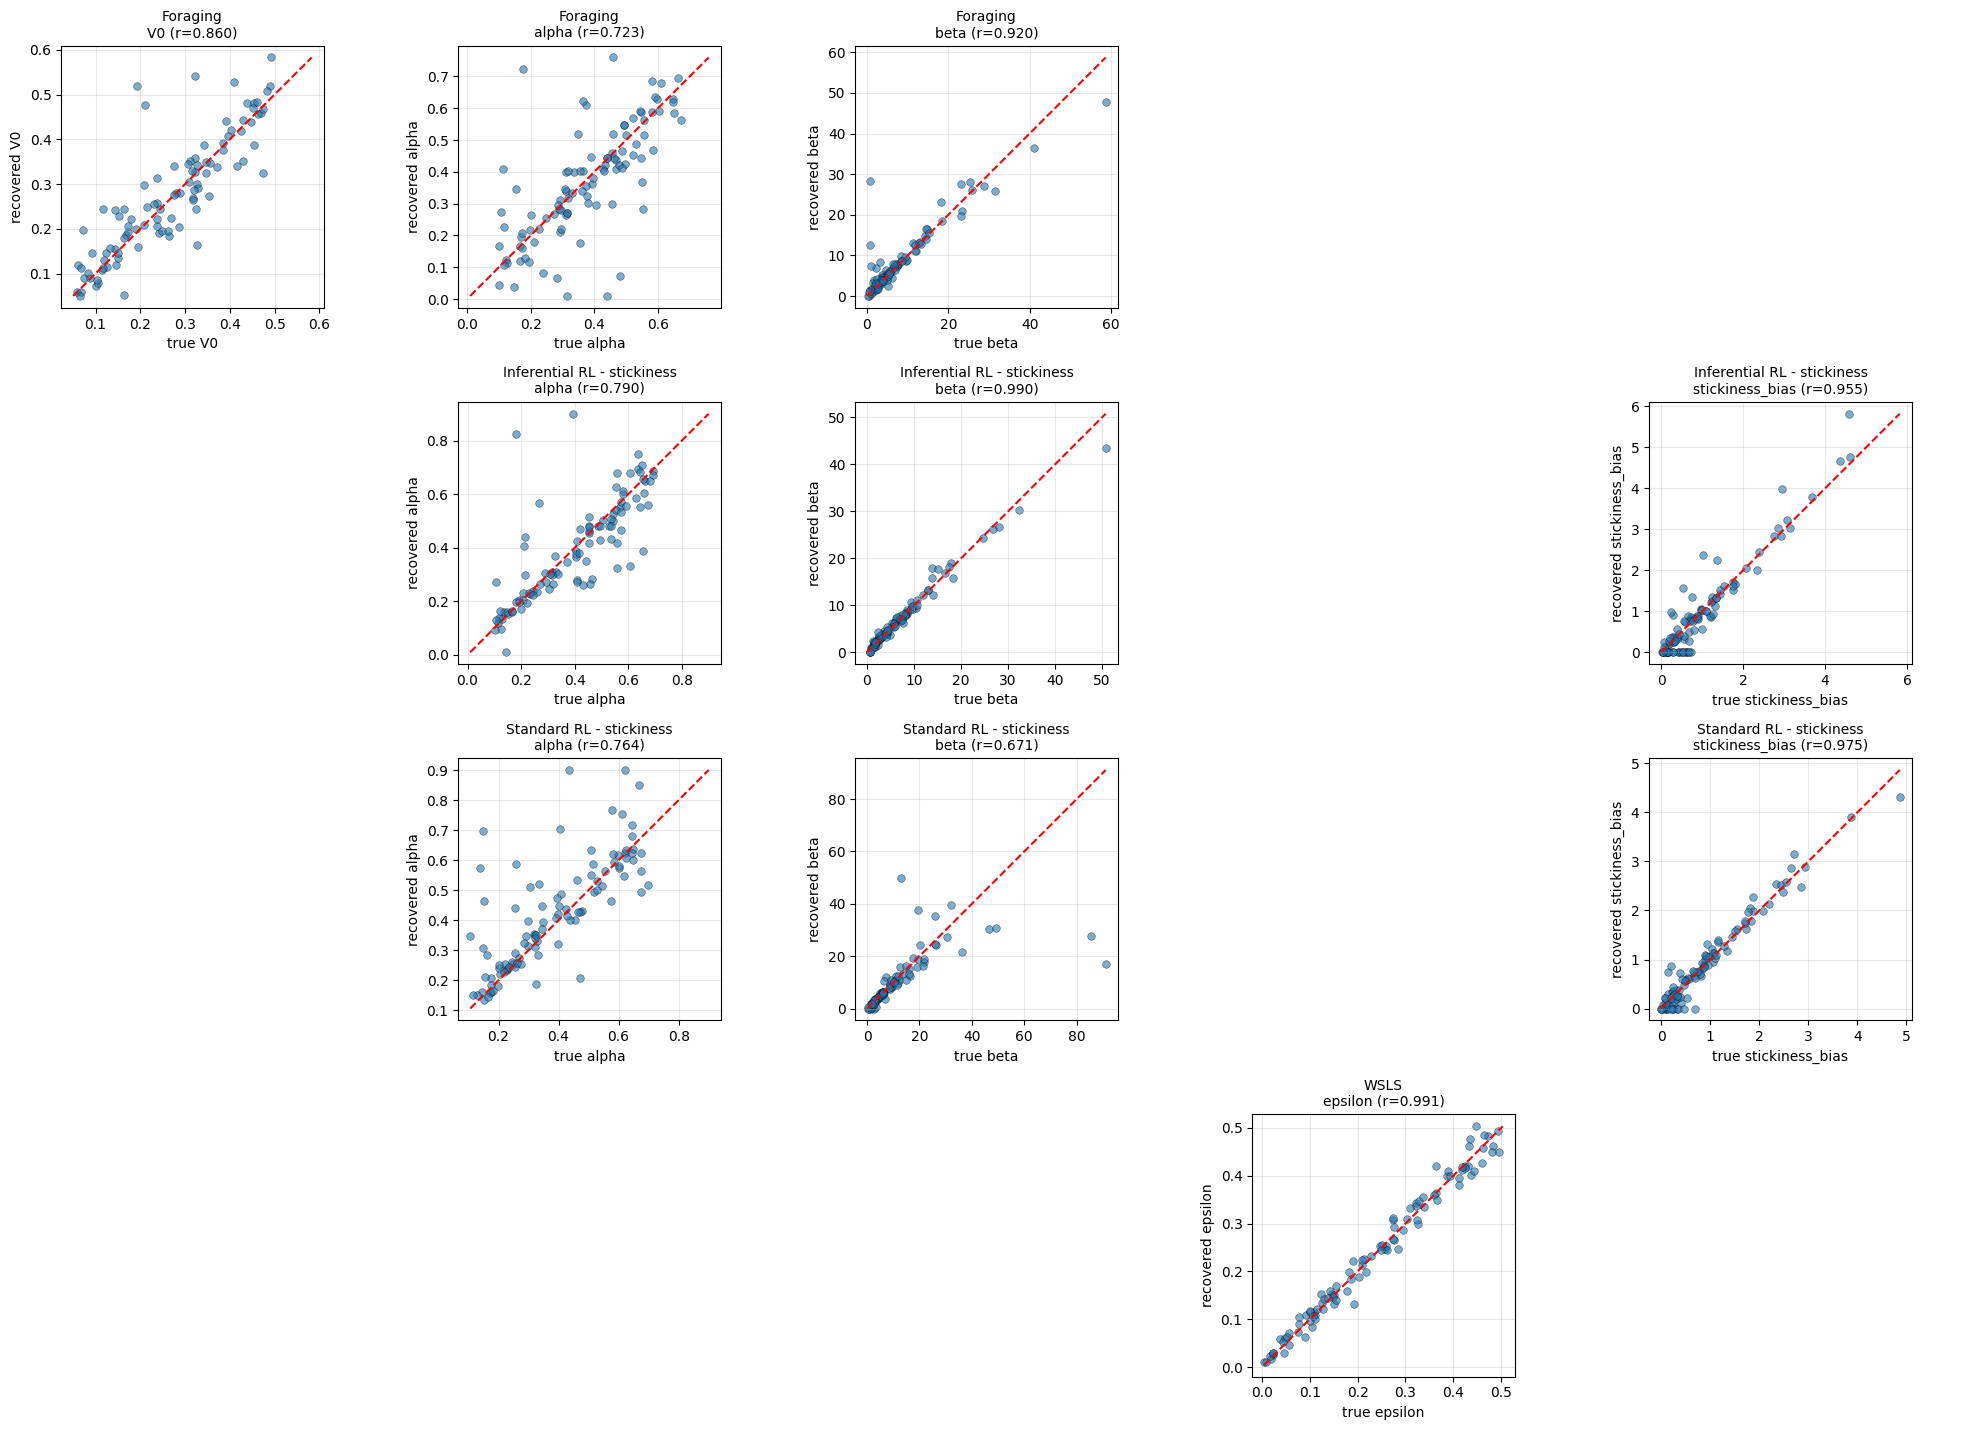

In [3]:
# Diagonal only (same true & fitted model)
df_diag = df[df["model_true"] == df["model_fitted"]].copy()
print(f"Diagonal rows (parameter recovery): {len(df_diag)}")
display(df_diag.head())

# Infer parameter names from *_recovered columns
recovered_cols = [c for c in df_diag.columns if c.endswith("_recovered")]
param_names = [c.replace("_recovered", "") for c in recovered_cols if c.replace("_recovered", "") in df_diag.columns]
param_names = sorted(set(param_names))
print("Detected parameters:", param_names)

models = list(pd.unique(df_diag["model_true"]))
print("Models (diagonal):", models)

# Plot: True vs recovered parameters (diagonal only), grouped by model
max_params = max(1, len(param_names))
fig, axes = plt.subplots(len(models), max_params, figsize=(4.0 * max_params, 3.6 * len(models)), squeeze=False)

for row_idx, model_name in enumerate(models):
    df_m = df_diag[df_diag["model_true"] == model_name]
    # Keep only params that actually exist for this model (non-NaN in either true or recovered)
    model_params = []
    for p in param_names:
        true_col = p
        rec_col = f"{p}_recovered"
        if true_col in df_m.columns and rec_col in df_m.columns:
            if df_m[[true_col, rec_col]].dropna().shape[0] > 0:
                model_params.append(p)

    for col_idx, p in enumerate(param_names):
        ax = axes[row_idx, col_idx]
        true_col = p
        rec_col = f"{p}_recovered"
        sub = df_m[[true_col, rec_col]].dropna() if (true_col in df_m.columns and rec_col in df_m.columns) else pd.DataFrame()

        if sub.empty:
            ax.axis("off")
            continue

        x = sub[true_col].to_numpy()
        y = sub[rec_col].to_numpy()
        ax.scatter(x, y, alpha=0.6, s=30, edgecolors="black", linewidth=0.4)

        # Identity line
        min_val = float(np.min([x.min(), y.min()]))
        max_val = float(np.max([x.max(), y.max()]))
        ax.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=1.5)

        # Correlation (guard against constant arrays)
        corr = np.corrcoef(x, y)[0, 1] if (np.std(x) > 0 and np.std(y) > 0) else np.nan
        ax.set_title(f"{model_name}\n{p} (r={corr:.3f})", fontsize=10)
        ax.set_xlabel(f"true {p}")
        ax.set_ylabel(f"recovered {p}")
        ax.grid(alpha=0.3)
        ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()

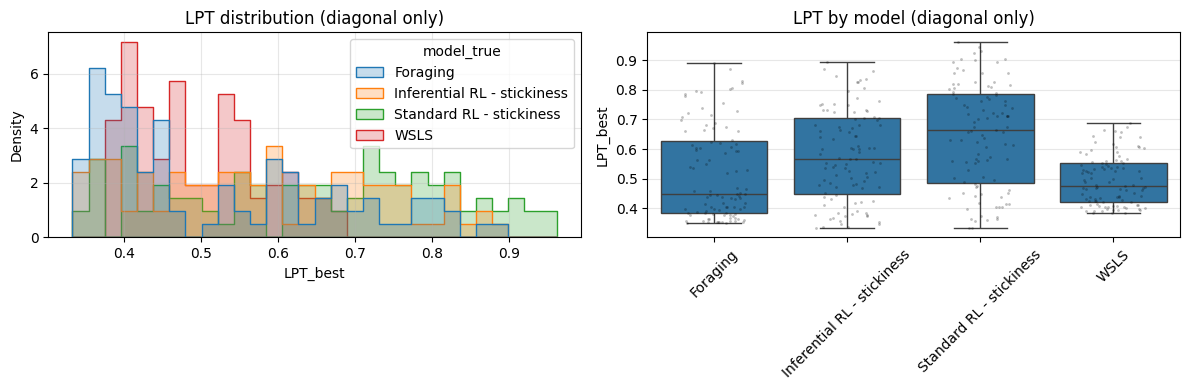

,count,mean,std,min,25%,50%,75%,max
model_true,,,,,,,,
Foraging,100.0,0.517657,0.154865,0.351968,0.384429,0.448007,0.626138,0.890519
Inferential RL - stickiness,100.0,0.576767,0.152355,0.334245,0.449402,0.566485,0.703166,0.893191
Standard RL - stickiness,100.0,0.645944,0.173903,0.333455,0.486955,0.662492,0.785752,0.961972
WSLS,100.0,0.494855,0.082812,0.382708,0.422306,0.475974,0.552309,0.686893


In [4]:
# Plot: LPT distributions per model (diagonal only)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overlaid histogram per model
sns.histplot(
    data=df_diag,
    x="LPT_best",
    hue="model_true",
    element="step",
    stat="density",
    common_norm=False,
    bins=30,
    ax=axes[0],
)
axes[0].set_title("LPT distribution (diagonal only)")
axes[0].set_xlabel("LPT_best")
axes[0].grid(alpha=0.3)

# Boxplot per model
sns.boxplot(data=df_diag, x="model_true", y="LPT_best", ax=axes[1])
sns.stripplot(data=df_diag, x="model_true", y="LPT_best", color="black", alpha=0.25, size=2, jitter=0.25, ax=axes[1])
axes[1].set_title("LPT by model (diagonal only)")
axes[1].set_xlabel("")
axes[1].set_ylabel("LPT_best")
axes[1].grid(alpha=0.3, axis="y")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# Quick summary
display(df_diag.groupby("model_true")["LPT_best"].describe())

## Confusion Matrix (Winner-Takes-All): % iterations each model is best
 
Instead of averaging LPT values, this version asks a simpler question per simulated dataset (iteration):
- For each **true model** and **iteration**, which **fitted model** achieved the highest `LPT_best`?
- The confusion matrix shows the **percentage of iterations** where each fitted model is the winner for that true model (rows sum to 100%).

/tmp/ipykernel_950131/1948605257.py:37: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


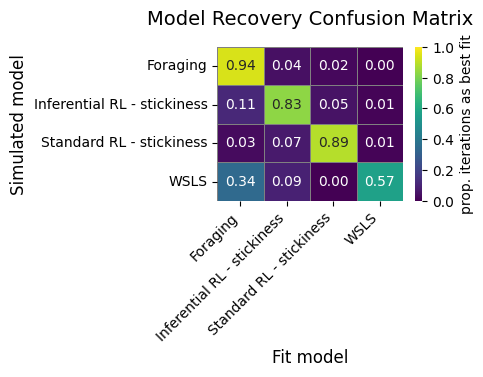

Win counts (rows=true model, cols=winning fitted model):


model_winner,Foraging,Inferential RL - stickiness,Standard RL - stickiness,WSLS
model_true,,,,
Foraging,94,4,2,0
Inferential RL - stickiness,11,83,5,1
Standard RL - stickiness,3,7,89,1
WSLS,34,9,0,57


Win proportion (%):


model_winner,Foraging,Inferential RL - stickiness,Standard RL - stickiness,WSLS
model_true,,,,
Foraging,0.94,0.04,0.02,0.00
Inferential RL - stickiness,0.11,0.83,0.05,0.01
Standard RL - stickiness,0.03,0.07,0.89,0.01
WSLS,0.34,0.09,0.00,0.57


In [5]:
# For each (true model, iteration), pick the fitted model with the highest LPT_best
required_cols = {"model_true", "model_fitted", "iteration", "LPT_best"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns in df: {sorted(missing)}")

# idx of the best-fitting model per (true model, iteration)
best_idx = df.groupby(["model_true", "iteration"])["LPT_best"].idxmax()
df_best = df.loc[best_idx, ["model_true", "model_fitted", "iteration", "LPT_best"]].copy()
df_best = df_best.rename(columns={"model_fitted": "model_winner"})

# Row-normalized counts -> percentage of wins
win_counts = pd.crosstab(df_best["model_true"], df_best["model_winner"])
win_pct = win_counts.div(win_counts.sum(axis=1), axis=0)

# Keep a consistent model ordering (if available)
model_order = sorted(pd.unique(df["model_true"]))
win_pct = win_pct.reindex(index=model_order, columns=model_order)

plt.figure(figsize=(3, 2))
sns.heatmap(
    win_pct,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "prop. iterations as best fit"},
    linewidths=0.5,
    linecolor="gray",
)
plt.title("Model Recovery Confusion Matrix", fontsize=14, pad=16)
plt.xlabel("Fit model", fontsize=12)
plt.ylabel("Simulated model", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Win counts (rows=true model, cols=winning fitted model):")
display(win_counts.reindex(index=model_order, columns=model_order).fillna(0).astype(int))

print("Win proportion (%):")
display(win_pct)